<a href="https://colab.research.google.com/github/esemsc-db24/Davide-Baino-Portfolio/blob/main/Transformeronfakedataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://natasha-klingenbrunn.medium.com/transformer-implementation-for-time-series-forecasting-a9db2db5c820

<a href="https://colab.research.google.com/github/ese-ada-lovelace-2024/irp-db24/blob/Modeldesigntransformer/SineTransformerVAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## import drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
## imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy
import numpy as np
import pandas as pd

In [3]:
## Import the preprocessed data from INHALE

In [4]:
preprocessed_data = pd.read_csv('/content/drive/MyDrive/results/processed_merged_dataset.csv')
preprocessed_data.drop(columns=["Unnamed: 0"], inplace=True)

In [5]:
preprocessed_data

,br_avg,br_std,act_level,step_count,pm2_5_x,pm2_5_y,pm10,no,no2,o3,...,yearly_cos,hour_sin,hour_cos,dow_sin,dow_cos,latitude_x,longitude_x,lat_round,lon_round,patient_id__patient_id
0,3.076146,0.209754,0.042995,0.000000,0.974560,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490046,-0.174493,51.490,-0.174,INH001
1,2.832208,1.781761,0.091346,0.000000,1.078410,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490049,-0.174472,51.490,-0.174,INH001
2,2.880227,2.141613,0.109832,0.000000,1.098612,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490052,-0.174474,51.490,-0.174,INH001
3,2.775554,1.767832,0.106791,2.079442,1.181727,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490128,-0.174413,51.490,-0.174,INH001
4,3.311010,0.324131,0.268083,4.276666,1.342865,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490206,-0.174305,51.490,-0.174,INH001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891404,2.746083,0.673601,0.006096,0.000000,0.792993,2.427454,2.957511,0.000000,2.551006,4.243626,...,0.158559,-0.258819,0.965926,0.781831,0.62349,51.472433,-0.209053,51.472,-0.209,INH139
891405,2.831237,1.242047,0.006261,0.000000,0.698135,2.427454,2.957511,0.000000,2.551006,4.243626,...,0.158559,-0.258819,0.965926,0.781831,0.62349,51.472422,-0.209052,51.472,-0.209,INH139
891406,2.799052,1.019858,0.008980,0.000000,0.741937,2.427454,2.957511,0.000000,2.551006,4.243626,...,0.158559,-0.258819,0.965926,0.781831,0.62349,51.472418,-0.209052,51.472,-0.209,INH139
891407,2.800097,0.726140,0.006749,0.000000,0.802002,2.427454,2.957511,0.000000,2.551006,4.243626,...,0.158559,-0.258819,0.965926,0.781831,0.62349,51.472421,-0.209044,51.472,-0.209,INH139


In [6]:
preprocessed_data.columns
clean_data = preprocessed_data.copy()
clean_data.drop_duplicates(inplace=True)

In [7]:
## Let's work a bit more on the data

## I am missing some columns (they disappear after the data preprocessing)
## Steps that need to happen are add daily, weekly and yearly
## Ad missing values
## Check a simple transformer and see if it works?
## Randomly select bit of the data and feed that to the model if it's a memory issue!

In [8]:
## USEFUL AFTER DATA DEBUGGING

## let's filter for the first 3 patients
clean_data = preprocessed_data[(preprocessed_data['patient_id__patient_id'] == "INH001")  |
                                     (preprocessed_data['patient_id__patient_id'] == "INH002") |
                                    (preprocessed_data['patient_id__patient_id'] == "INH003")].copy()

# clean_data = clean_data.drop(columns=['patient_id__patient_id'])


In [9]:
clean_data.head()
# print(list(clean_data.columns))

,br_avg,br_std,act_level,step_count,pm2_5_x,pm2_5_y,pm10,no,no2,o3,...,yearly_cos,hour_sin,hour_cos,dow_sin,dow_cos,latitude_x,longitude_x,lat_round,lon_round,patient_id__patient_id
0,3.076146,0.209754,0.042995,0.000000,0.974560,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490046,-0.174493,51.49,-0.174,INH001
1,2.832208,1.781761,0.091346,0.000000,1.078410,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490049,-0.174472,51.49,-0.174,INH001
2,2.880227,2.141613,0.109832,0.000000,1.098612,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490052,-0.174474,51.49,-0.174,INH001
3,2.775554,1.767832,0.106791,2.079442,1.181727,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490128,-0.174413,51.49,-0.174,INH001
4,3.311010,0.324131,0.268083,4.276666,1.342865,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,51.490206,-0.174305,51.49,-0.174,INH001


In [10]:
## USEFUL TO VISUALIZE THE DATA

# import matplotlib.pyplot as plt
# index = 500

# plt.figure(figsize=(12, 6))
# plt.plot(clean_data['br_avg'].iloc[:index], label='Breath Rate (br_avg)', color='blue')
# plt.title('Breath Rate Over First 500 Timesteps')
# plt.xlabel('Time Step')
# plt.ylabel('Breath Rate (br_avg)')
# plt.grid()
# plt.legend()
# plt.show()


In [11]:
## to do:
# 1. Drop 2 of these lat_round - latitude_x, lon_round, longitude_x
# 2. Is the data preprocessed? If not, we need to preprocess it.
# 3. Check again loss calculation because I believe there is something wrong

## DATA DEBUGGING

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

clean_data[['latitude_x', 'longitude_x', 'lat_round', 'lon_round']] = scaler.fit_transform(
    clean_data[['latitude_x', 'longitude_x', 'lat_round', 'lon_round']]
)


In [14]:
clean_data

,br_avg,br_std,act_level,step_count,pm2_5_x,pm2_5_y,pm10,no,no2,o3,...,yearly_cos,hour_sin,hour_cos,dow_sin,dow_cos,latitude_x,longitude_x,lat_round,lon_round,patient_id__patient_id
0,3.076146,0.209754,0.042995,0.000000,0.974560,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,0.048446,0.685326,0.053826,0.690856,INH001
1,2.832208,1.781761,0.091346,0.000000,1.078410,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,0.048576,0.685602,0.053826,0.690856,INH001
2,2.880227,2.141613,0.109832,0.000000,1.098612,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,0.048704,0.685571,0.053826,0.690856,INH001
3,2.775554,1.767832,0.106791,2.079442,1.181727,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,0.052106,0.686353,0.053826,0.690856,INH001
4,3.311010,0.324131,0.268083,4.276666,1.342865,1.000632,1.205971,0.512824,2.628285,4.293742,...,0.598181,0.707107,-0.707107,0.781831,0.62349,0.055614,0.687754,0.053826,0.690856,INH001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59977,2.418646,0.329489,0.006010,0.000000,1.954445,1.420696,1.470176,0.000000,1.786747,3.918999,...,-0.998186,-0.258819,0.965926,0.000000,1.00000,-0.837755,0.383022,-0.840375,0.380271,INH003
59978,2.613644,1.101929,0.023064,0.000000,1.896119,1.420696,1.470176,0.000000,1.786747,3.918999,...,-0.998186,-0.258819,0.965926,0.000000,1.00000,-0.838457,0.383339,-0.840375,0.380271,INH003
59979,2.697732,0.561459,0.008505,0.000000,1.871802,1.420696,1.470176,0.000000,1.786747,3.918999,...,-0.998186,-0.258819,0.965926,0.000000,1.00000,-0.837031,0.382731,-0.840375,0.380271,INH003
59980,2.599464,0.555383,0.006523,0.000000,1.854734,1.420696,1.470176,0.000000,1.786747,3.918999,...,-0.998186,-0.258819,0.965926,0.000000,1.00000,-0.835992,0.383227,-0.840375,0.380271,INH003


# DATA SHAPE

In [15]:
# IS THE DATA SHAPE CORRECT ETC

print("Shape:", clean_data.shape)

print("\nColumns:")
print(clean_data.columns.tolist())

print("\nData Types:")
print(clean_data.dtypes)

print("\nMissing Values Per Column:")
print(clean_data.isna().sum())

print("\nDuplicate Rows:", clean_data.duplicated().sum())

print("\nDescriptive Statistics:")
print(clean_data.describe())


Shape: (59980, 51)

Columns:
['br_avg', 'br_std', 'act_level', 'step_count', 'pm2_5_x', 'pm2_5_y', 'pm10', 'no', 'no2', 'o3', 'so2', 'co', 'age', 'temperature', 'humidity', 'month', 'week_of_year', 'day_of_year', 'sex_Female', 'sex_Male', 'season_x_Summer', 'season_x_Winter', 'activity_Lying down on back', 'activity_Lying down on front', 'activity_Lying down to the left', 'activity_Lying down to the right', 'activity_Movement', 'activity_Sitting bent backwards', 'activity_Sitting bent forwards', 'activity_Sitting straight/Standing', 'activity_Undefined', 'activity_Walking', 'health_ashmatic', 'health_healthy', 'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter', 'is_weekend_False', 'is_weekend_True', 'yearly_sin', 'yearly_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'latitude_x', 'longitude_x', 'lat_round', 'lon_round', 'patient_id__patient_id']

Data Types:
br_avg                                float64
br_std                                float64
act_level      

# WHAT ABOUT SEQUENCE TIME CONSINSTENCY?
# Are they continuous? Is there any gap
# Are sequences all the same lenght?
# Do sequences leak across patients?



Cyclical Columns Detected:
['yearly_sin', 'yearly_cos', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


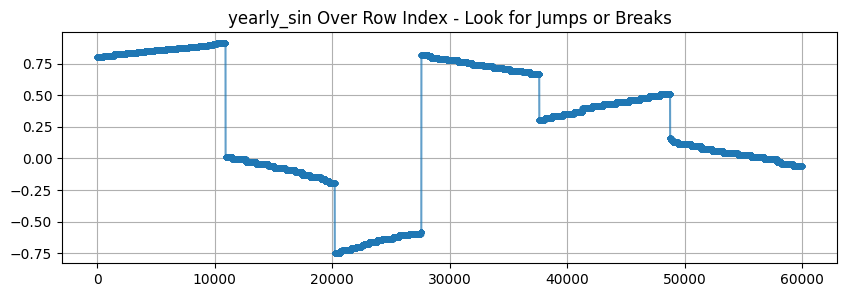

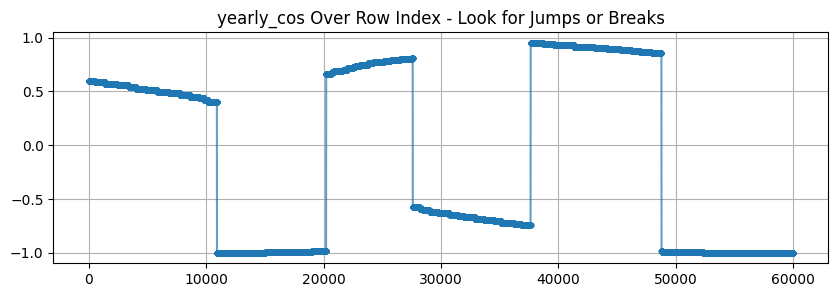

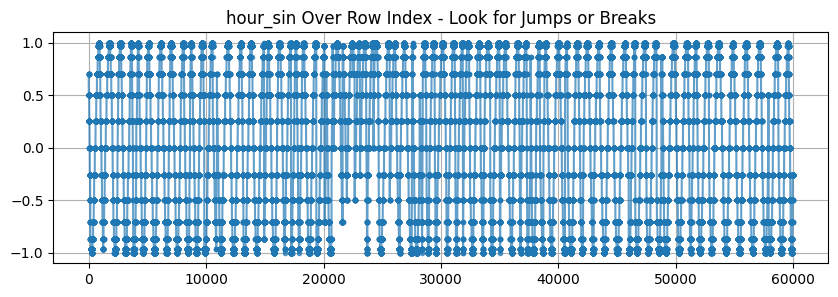

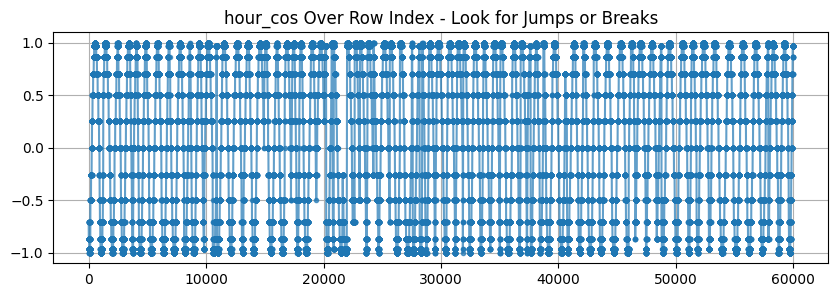

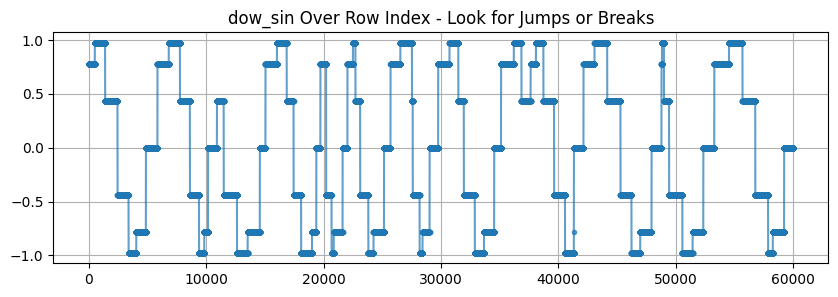

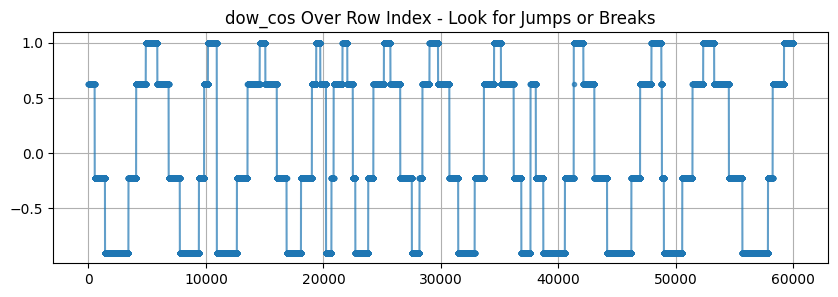

In [16]:
# I need to figure out if I am respecting sequential continuity

import matplotlib.pyplot as plt
import numpy as np

# === Replace these with your actual cyclical columns ===
cyclical_cols = [col for col in clean_data.columns if 'sin' in col or 'cos' in col]

print("\nCyclical Columns Detected:")
print(cyclical_cols)

# === Plot each cyclical column to visually inspect smoothness ===
for col in cyclical_cols:
    plt.figure(figsize=(10, 3))
    plt.plot(clean_data[col].values, marker='.', linestyle='-', alpha=0.7)
    plt.title(f"{col} Over Row Index - Look for Jumps or Breaks")
    plt.grid()
    plt.show()


# RANGE OF VALUES
# Are they in the same range of values? Do I need to preprocess?
# Are cyclical features properly scaled?

In [17]:
## Cyclical features were scaled and that was a problem!

## CREATING FAKE DATA

In [47]:
import pandas as pd
import numpy as np

# === Config ===
num_patients = 3
timesteps_per_patient = 500
num_features = 5  # Number of features excluding patient_id

# Choose a start datetime for each patient’s measurements
start_date = pd.to_datetime('2020-01-01')

all_data = []

# Pre‑define for each feature a random amplitude, period (in hours), and phase shift
amps   = np.random.uniform(0.5, 1.5, size=num_features)
periods = np.random.uniform(24, 200, size=num_features)   # e.g. between daily and ~8‑day cycles
phases = np.random.uniform(0, 2*np.pi, size=num_features)

for pid in range(num_patients):
    patient_id = f"PAT{pid+1:03d}"

    # build the base time array in hours since start
    t = np.arange(timesteps_per_patient)

    # compute each feature as: amp * sin(2π t / period + phase)
    features = np.stack([
        amps[i] * np.sin(2 * np.pi * t / periods[i] + phases[i])
        for i in range(num_features)
    ], axis=1)

    df = pd.DataFrame(
        features,
        columns=[f'feature_{i}' for i in range(num_features)]
    )
    df['patient_id__patient_id'] = patient_id

    # create a datetime index at hourly intervals
    df['datetime'] = pd.date_range(
        start=start_date,
        periods=timesteps_per_patient,
        freq='H'
    )

    # extract calendar components
    df['hour']   = df['datetime'].dt.hour
    df['day']    = df['datetime'].dt.day
    df['month']  = df['datetime'].dt.month

    # cyclical (sin/cos) transforms
    df['sin_hour']   = np.sin(2 * np.pi * df['hour']   / 24)
    df['cos_hour']   = np.cos(2 * np.pi * df['hour']   / 24)
    df['sin_day']    = np.sin(2 * np.pi * df['day']    / 31)
    df['cos_day']    = np.cos(2 * np.pi * df['day']    / 31)
    df['sin_month']  = np.sin(2 * np.pi * df['month']  / 12)
    df['cos_month']  = np.cos(2 * np.pi * df['month']  / 12)

    # drop raw calendar cols if you like
    df = df.drop(columns=["hour", "day", "month"])
    # (you can also drop datetime if you don't need it)

    all_data.append(df)

# === Final DataFrame ===
fake_df = pd.concat(all_data, ignore_index=True)
print(fake_df.head(10))


   feature_0  feature_1  feature_2  feature_3  feature_4  \
0   0.352083  -0.997106   0.539254   0.126133   0.145585   
1   0.144707  -0.996896   0.557631   0.156941   0.109248   
2  -0.065619  -0.994752   0.572166   0.187202   0.072505   
3  -0.274607  -0.990678   0.582760   0.216808   0.035493   
4  -0.477997  -0.984682   0.589339   0.245657  -0.001650   
5  -0.671642  -0.976777   0.591859   0.273647  -0.038788   
6  -0.851593  -0.966976   0.590302   0.300682  -0.075781   
7  -1.014182  -0.955299   0.584679   0.326665  -0.112493   
8  -1.156094  -0.941769   0.575028   0.351507  -0.148788   
9  -1.274436  -0.926412   0.561416   0.375121  -0.184531   

  patient_id__patient_id            datetime  sin_hour      cos_hour  \
0                 PAT001 2020-01-01 00:00:00  0.000000  1.000000e+00   
1                 PAT001 2020-01-01 01:00:00  0.258819  9.659258e-01   
2                 PAT001 2020-01-01 02:00:00  0.500000  8.660254e-01   
3                 PAT001 2020-01-01 03:00:00  0.707

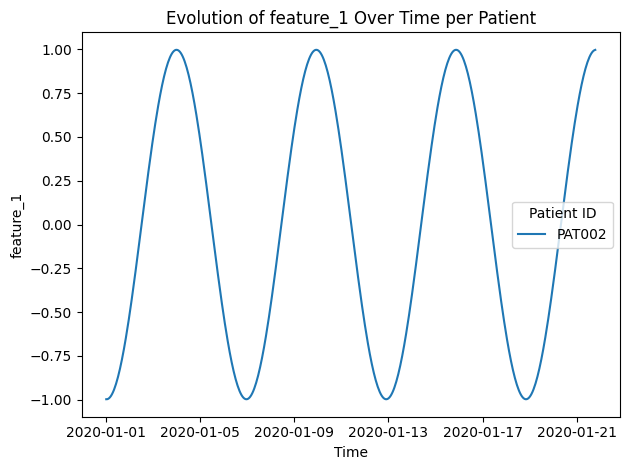

In [49]:
# Plot feature_1 over time per patient
first_plot = "PAT002"
dataframe_to_plot = fake_df[fake_df['patient_id__patient_id'] == first_plot].copy()

plt.figure()
for pid, group in dataframe_to_plot.groupby('patient_id__patient_id'):
    plt.plot(group['datetime'], group['feature_1'], label=pid)

plt.xlabel('Time')
plt.ylabel('feature_1')
plt.title('Evolution of feature_1 Over Time per Patient')
plt.legend(title='Patient ID')
plt.tight_layout()
plt.show()

In [50]:
class PatientForecastDataset(Dataset):
    def __init__(self, dataframe, patient_ids, seq_len=50, forecast_steps=10, stride=1):
        """
        Args:
            dataframe (pd.DataFrame): Full dataset including all patients
            patient_ids (list): List of patient IDs to include in this dataset (train or test)
            seq_len (int): Length of the input sequence
            forecast_steps (int): Number of steps to forecast
            stride (int): Step size to slide the window
        """
        self.seq_len = seq_len
        self.forecast_steps = forecast_steps
        self.sequences = []

        for pid in patient_ids:
            ## Filter for first patient_id
            patient_data = dataframe[dataframe['patient_id__patient_id'] == pid]
            ## Drop the patient_id column and keep only feature columns
            feature_columns = [f'feature_{i}' for i in range(5)]  # Only the 5 features
            patient_data = patient_data[feature_columns].reset_index(drop=True)
            ## Import it into tensor
            data_tensor = torch.tensor(patient_data.values, dtype=torch.float32)
            total_timesteps = data_tensor.shape[0]

            num_full_sequences = (total_timesteps - (seq_len + forecast_steps)) + 1

            if num_full_sequences <= 0:
                continue  # Not enough data for even one sequence

            for start in range(0, num_full_sequences, stride):
                end = start + seq_len + forecast_steps
                sequence = data_tensor[start:end]

                input_part = sequence[:seq_len]
                future_part = sequence[seq_len:]

                self.sequences.append((input_part, future_part))

        print(f"Loaded {len(self.sequences)} sequences for {len(patient_ids)} patients.")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

In [51]:
## Here I am creating an instance of the class

import numpy as np
import torch
from torch.utils.data import DataLoader

dataframe_to_use = fake_df

# === Split by Patients ===
unique_patients = dataframe_to_use['patient_id__patient_id'].unique()
np.random.shuffle(unique_patients)


train_frac = 0.8
split_idx = int(train_frac * len(unique_patients))

train_patients = unique_patients[:split_idx]
test_patients = unique_patients[split_idx:]


print(f"Train Patients: {len(train_patients)}, Test Patients: {len(test_patients)}")

# === Instantiate Datasets ===
seq_len = 20
forecast_steps = 20
batch_size = 64
stride = 10

train_dataset = PatientForecastDataset(dataframe_to_use, train_patients, seq_len, forecast_steps, stride = stride)
test_dataset = PatientForecastDataset(dataframe_to_use, test_patients, seq_len, forecast_steps, stride = stride)

# print(f"Train sequences: {len(train_dataset)}, Test sequences: {len(test_dataset)}")

# === DataLoaders ===
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for i in range(1):
    x, y = train_dataset[i]
    print(f"\nSequence {i}: Input shape: {x.shape}, Target shape: {y.shape}")
    print(x)
    print(y)



Train Patients: 2, Test Patients: 1
Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.

Sequence 0: Input shape: torch.Size([20, 5]), Target shape: torch.Size([20, 5])
tensor([[ 0.3521, -0.9971,  0.5393,  0.1261,  0.1456],
        [ 0.1447, -0.9969,  0.5576,  0.1569,  0.1092],
        [-0.0656, -0.9948,  0.5722,  0.1872,  0.0725],
        [-0.2746, -0.9907,  0.5828,  0.2168,  0.0355],
        [-0.4780, -0.9847,  0.5893,  0.2457, -0.0017],
        [-0.6716, -0.9768,  0.5919,  0.2736, -0.0388],
        [-0.8516, -0.9670,  0.5903,  0.3007, -0.0758],
        [-1.0142, -0.9553,  0.5847,  0.3267, -0.1125],
        [-1.1561, -0.9418,  0.5750,  0.3515, -0.1488],
        [-1.2744, -0.9264,  0.5614,  0.3751, -0.1845],
        [-1.3668, -0.9093,  0.5439,  0.3974, -0.2196],
        [-1.4313, -0.8903,  0.5227,  0.4183, -0.2538],
        [-1.4666, -0.8697,  0.4979,  0.4378, -0.2871],
        [-1.4720, -0.8474,  0.4696,  0.4557, -0.3194],
        [-1.4474, -0.8234,  0.4381,  0.47

## FORECAST TRANSFORMER

In [57]:
import torch
import torch.nn as nn
import math
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# === Positional Encoding ===
class PositionalEncoding(nn.Module):
    """
    Implements the standard sinusoidal positional encoding.
    """
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)  # (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (seq_len, batch, d_model)
        x = x + self.pe[:x.size(0)]
        return x


# === TimeSeries Transformer ===
class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        feature_size: int,
        d_model: int = 64,
        nhead: int = 8,
        num_layers: int = 3,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        forecast_steps: int = 10,
    ):
        super().__init__()
        # project input features to model dimension
        self.input_proj = nn.Linear(feature_size, d_model)
        # positional encoding
        self.pos_encoder = PositionalEncoding(d_model)
        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )
        # output decoder: mapping last hidden to forecast steps
        self.decoder = nn.Linear(d_model, forecast_steps)
        self.d_model = d_model

    def forward(self, src: torch.Tensor) -> torch.Tensor:
        """
        Args:
            src: (seq_len, batch, feature_size)
        Returns:
            out: (batch, forecast_steps)
        """
        # project and scale
        x = self.input_proj(src) * math.sqrt(self.d_model)
        # add positional encoding
        x = self.pos_encoder(x)
        # encode
        enc_out = self.transformer_encoder(x)  # (seq_len, batch, d_model)
        # take last time-step
        last = enc_out[-1, :, :]               # (batch, d_model)
        # predict
        out = self.decoder(last)               # (batch, forecast_steps)
        return out


# === Training Loop ===
def train_model(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int = 20,
):
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        for inputs, targets in dataloader:
            # inputs: (batch, seq_len, features)
            # targets: (batch, forecast_steps, features)
            inputs = inputs.permute(1, 0, 2).to(device)  # (seq_len, batch, features)
            # only predict the first feature
            targets = targets[:, :, 0].to(device)        # (batch, forecast_steps)
            optimizer.zero_grad()
            outputs = model(inputs)                      # (batch, forecast_steps)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_loss:.6f}")


# === Evaluation ===
def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
):
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.permute(1, 0, 2).to(device)
            outputs = model(inputs)                    # (batch, forecast_steps)
            all_preds.append(outputs.cpu())
            all_trues.append(targets[:, :, 0])        # (batch, forecast_steps)
    preds = torch.cat(all_preds, dim=0)
    trues = torch.cat(all_trues, dim=0)
    return preds, trues



## TRAINING LOOP

▶️  Starting training …
Epoch 1/50 - Train Loss: 1.206511
Epoch 2/50 - Train Loss: 0.863120
Epoch 3/50 - Train Loss: 0.641349
Epoch 4/50 - Train Loss: 0.468155
Epoch 5/50 - Train Loss: 0.322105
Epoch 6/50 - Train Loss: 0.213781
Epoch 7/50 - Train Loss: 0.133383
Epoch 8/50 - Train Loss: 0.087347
Epoch 9/50 - Train Loss: 0.057886
Epoch 10/50 - Train Loss: 0.048658
Epoch 11/50 - Train Loss: 0.040893
Epoch 12/50 - Train Loss: 0.032271
Epoch 13/50 - Train Loss: 0.033701
Epoch 14/50 - Train Loss: 0.029716
Epoch 15/50 - Train Loss: 0.031219
Epoch 16/50 - Train Loss: 0.028345
Epoch 17/50 - Train Loss: 0.026816
Epoch 18/50 - Train Loss: 0.025122
Epoch 19/50 - Train Loss: 0.024859
Epoch 20/50 - Train Loss: 0.021185
Epoch 21/50 - Train Loss: 0.018335
Epoch 22/50 - Train Loss: 0.019546
Epoch 23/50 - Train Loss: 0.018428
Epoch 24/50 - Train Loss: 0.015641
Epoch 25/50 - Train Loss: 0.015646
Epoch 26/50 - Train Loss: 0.015824
Epoch 27/50 - Train Loss: 0.015614
Epoch 28/50 - Train Loss: 0.015194
Epoch

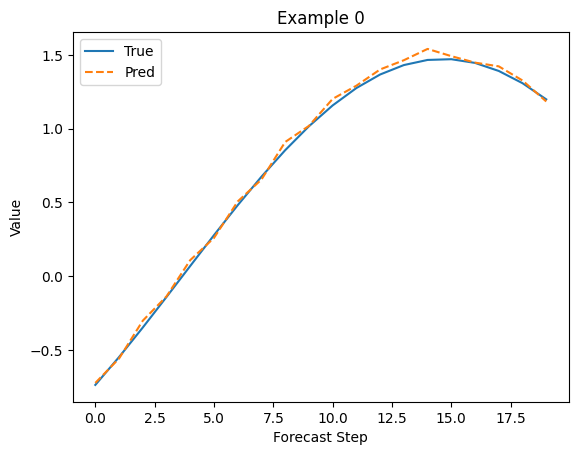

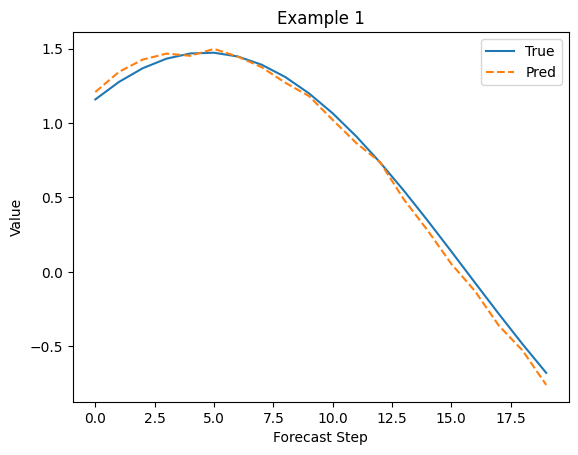

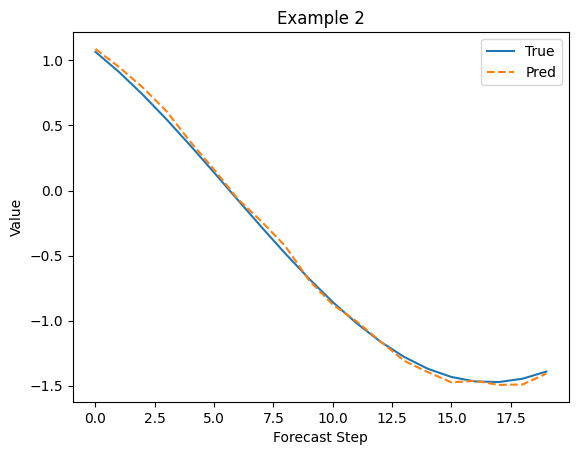

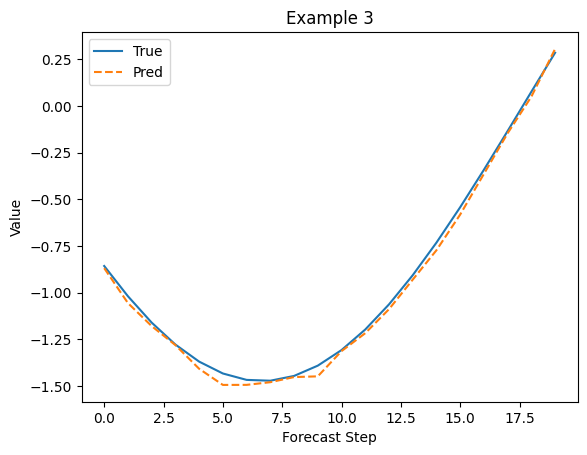

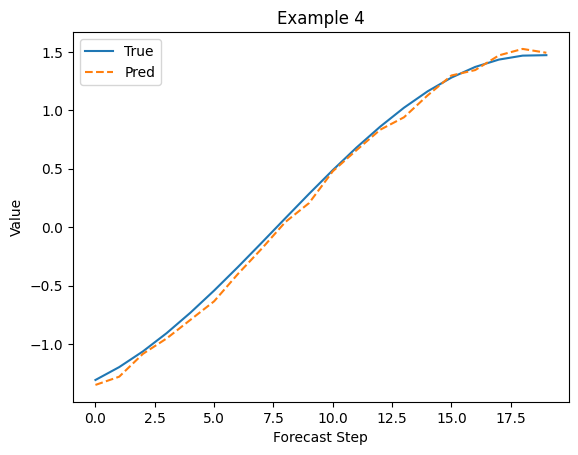

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.276863


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 2/50 - Train Loss: 0.903039
Epoch 3/50 - Train Loss: 0.669474
Epoch 4/50 - Train Loss: 0.479741
Epoch 5/50 - Train Loss: 0.330537
Epoch 6/50 - Train Loss: 0.214609
Epoch 7/50 - Train Loss: 0.131053
Epoch 8/50 - Train Loss: 0.082939
Epoch 9/50 - Train Loss: 0.053051
Epoch 10/50 - Train Loss: 0.044539
Epoch 11/50 - Train Loss: 0.036348
Epoch 12/50 - Train Loss: 0.033378
Epoch 13/50 - Train Loss: 0.033885
Epoch 14/50 - Train Loss: 0.036689
Epoch 15/50 - Train Loss: 0.032356
Epoch 16/50 - Train Loss: 0.034097
Epoch 17/50 - Train Loss: 0.029301
Epoch 18/50 - Train Loss: 0.028889
Epoch 19/50 - Train Loss: 0.024641
Epoch 20/50 - Train Loss: 0.022133
Epoch 21/50 - Train Loss: 0.020640
Epoch 22/50 - Train Loss: 0.018632
Epoch 23/50 - Train Loss: 0.017444
Epoch 24/50 - Train Loss: 0.016680
Epoch 25/50 - Train Loss: 0.019038
Epoch 26/50 - Train Loss: 0.018554
Epoch 27/50 - Train Loss: 0.016784
Epoch 28/50 - Train Loss: 0.016780
Epoch 29/50 - Train Loss: 0.016190
Epoch 30/50 - Train Loss: 0.

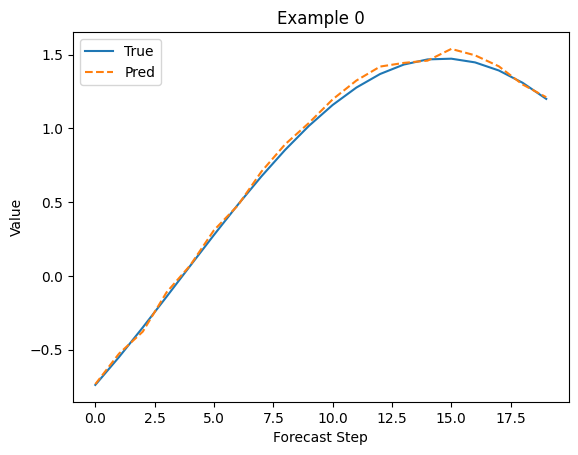

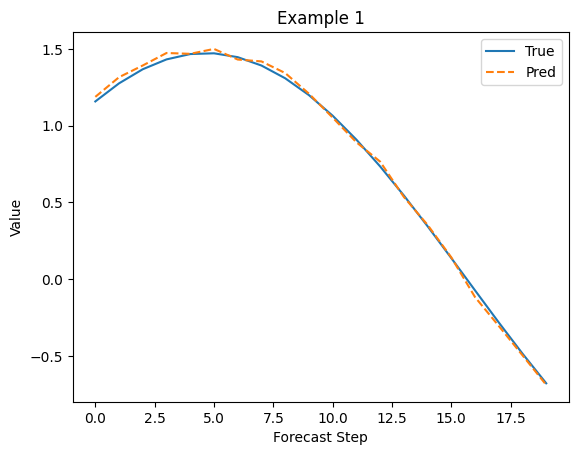

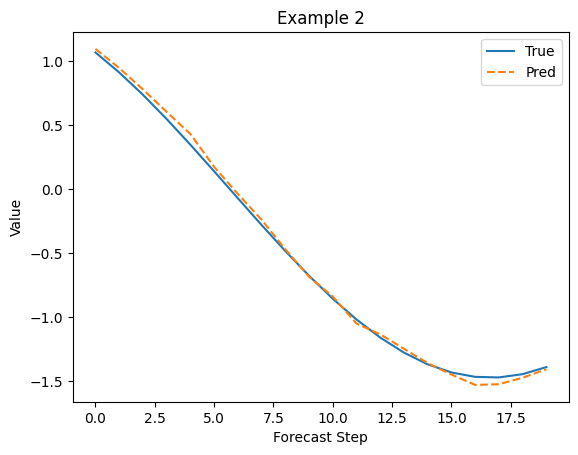

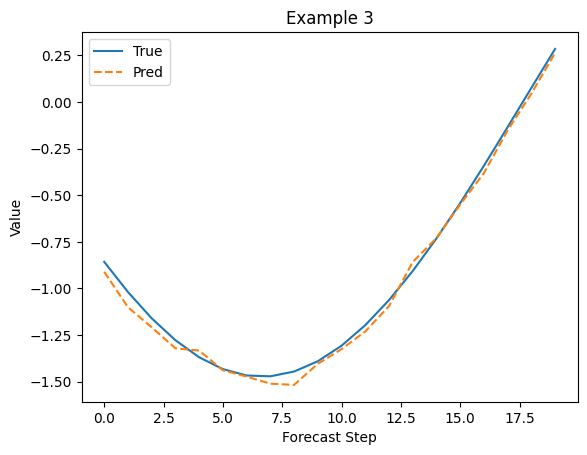

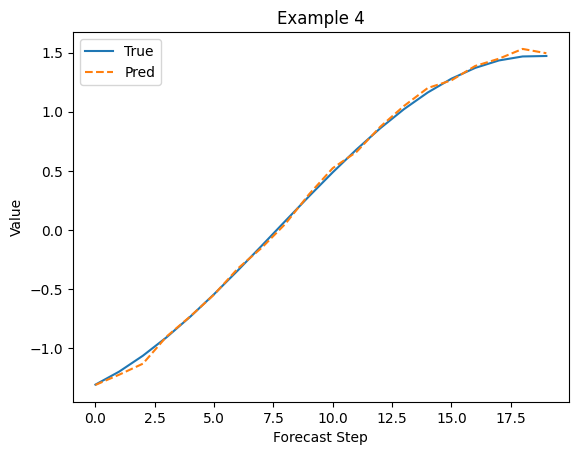

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.190481


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 2/50 - Train Loss: 0.783014
Epoch 3/50 - Train Loss: 0.517809
Epoch 4/50 - Train Loss: 0.338010
Epoch 5/50 - Train Loss: 0.202388
Epoch 6/50 - Train Loss: 0.130081
Epoch 7/50 - Train Loss: 0.082037
Epoch 8/50 - Train Loss: 0.057087
Epoch 9/50 - Train Loss: 0.044356
Epoch 10/50 - Train Loss: 0.034296
Epoch 11/50 - Train Loss: 0.032483
Epoch 12/50 - Train Loss: 0.032117
Epoch 13/50 - Train Loss: 0.032385
Epoch 14/50 - Train Loss: 0.032044
Epoch 15/50 - Train Loss: 0.028472
Epoch 16/50 - Train Loss: 0.027623
Epoch 17/50 - Train Loss: 0.023840
Epoch 18/50 - Train Loss: 0.021052
Epoch 19/50 - Train Loss: 0.021912
Epoch 20/50 - Train Loss: 0.017186
Epoch 21/50 - Train Loss: 0.018319
Epoch 22/50 - Train Loss: 0.016021
Epoch 23/50 - Train Loss: 0.017220
Epoch 24/50 - Train Loss: 0.016989
Epoch 25/50 - Train Loss: 0.017184
Epoch 26/50 - Train Loss: 0.016804
Epoch 27/50 - Train Loss: 0.015887
Epoch 28/50 - Train Loss: 0.015482
Epoch 29/50 - Train Loss: 0.014425
Epoch 30/50 - Train Loss: 0.

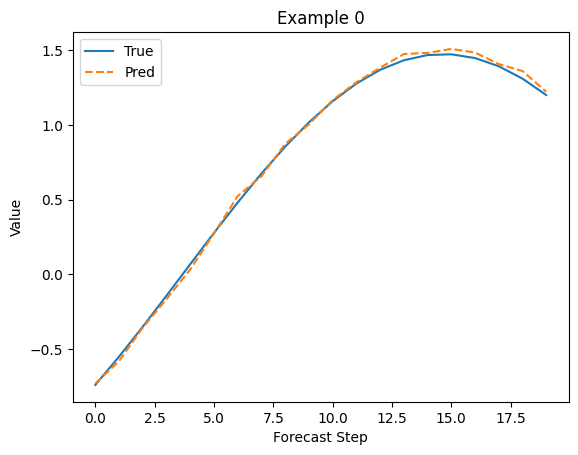

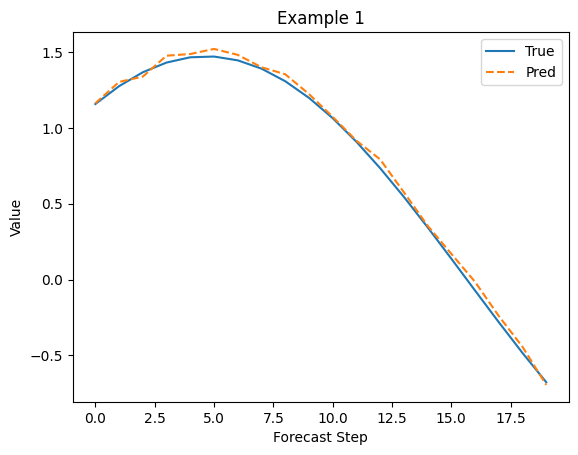

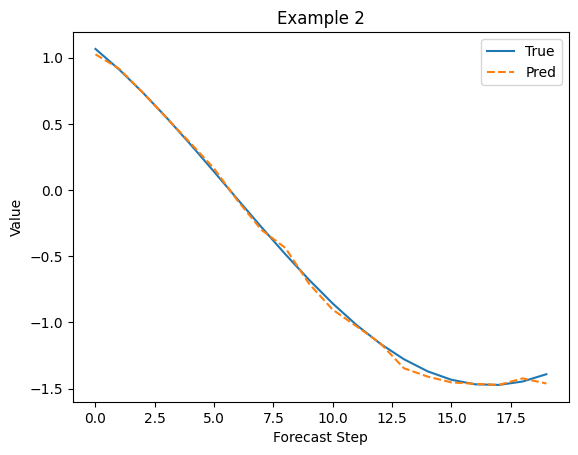

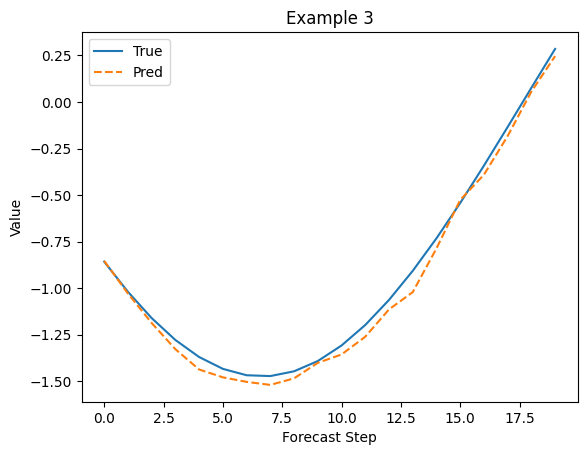

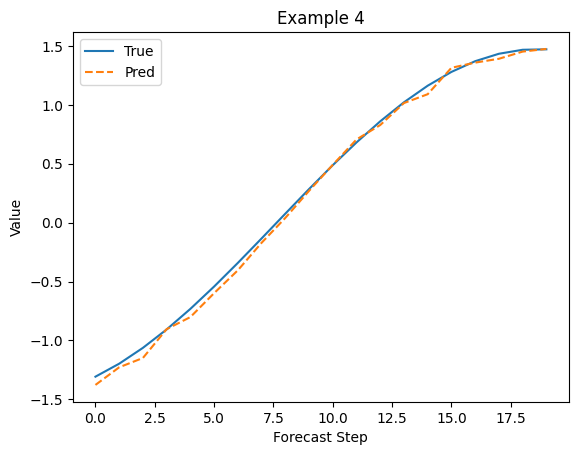

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.540437
Epoch 2/50 - Train Loss: 1.075719
Epoch 3/50 - Train Loss: 0.850052
Epoch 4/50 - Train Loss: 0.670222
Epoch 5/50 - Train Loss: 0.528933
Epoch 6/50 - Train Loss: 0.411377
Epoch 7/50 - Train Loss: 0.337060
Epoch 8/50 - Train Loss: 0.243215
Epoch 9/50 - Train Loss: 0.165864
Epoch 10/50 - Train Loss: 0.115632
Epoch 11/50 - Train Loss: 0.088323
Epoch 12/50 - Train Loss: 0.060449
Epoch 13/50 - Train Loss: 0.052141
Epoch 14/50 - Train Loss: 0.050214
Epoch 15/50 - Train Loss: 0.038224
Epoch 16/50 - Train Loss: 0.034771
Epoch 17/50 - Train Loss: 0.033104
Epoch 18/50 - Train Loss: 0.033699
Epoch 19/50 - Train Loss: 0.032995
Epoch 20/50 - Train Loss: 0.029364
Epoch 21/50 - Train Loss: 0.025455
Epoch 22/50 - Train Loss: 0.023805
Epoch 23/50 - Train Loss: 0.021898
Epoch 24/50 - Train Loss: 0.021234
Epoch 25/50 - Train Loss: 0.020437
Epoch 26/50 - Train Loss: 0.019200
Epoch 27/50 - Train Loss: 0

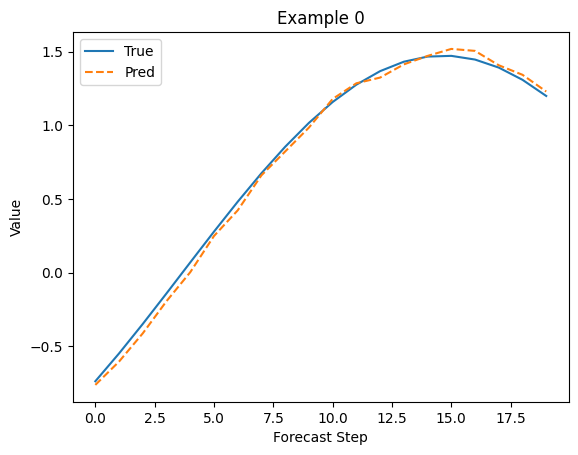

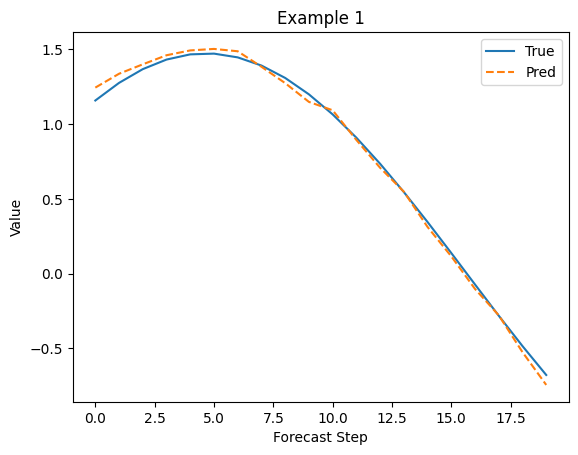

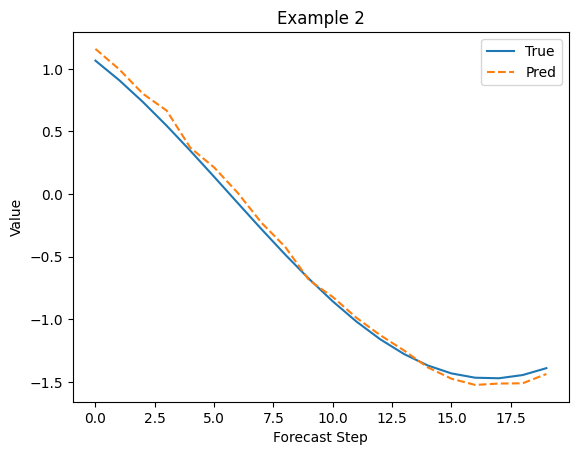

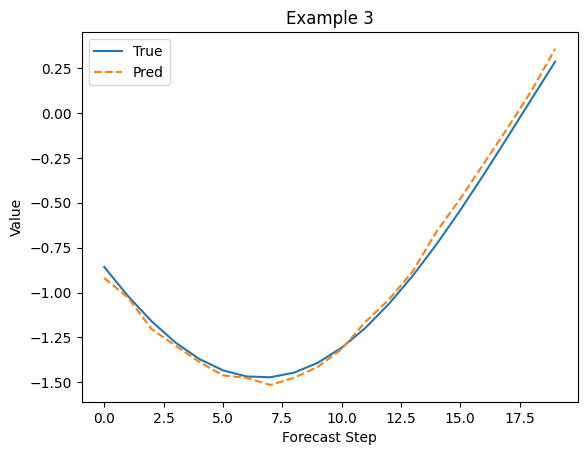

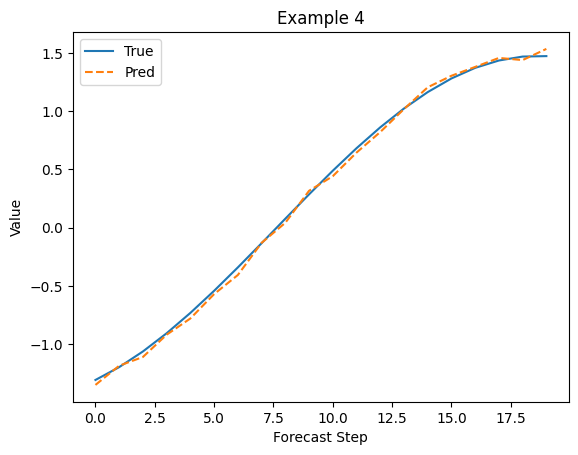

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.249207


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 2/50 - Train Loss: 0.950441
Epoch 3/50 - Train Loss: 0.726780
Epoch 4/50 - Train Loss: 0.532773
Epoch 5/50 - Train Loss: 0.389409
Epoch 6/50 - Train Loss: 0.279374
Epoch 7/50 - Train Loss: 0.201640
Epoch 8/50 - Train Loss: 0.140687
Epoch 9/50 - Train Loss: 0.102378
Epoch 10/50 - Train Loss: 0.073670
Epoch 11/50 - Train Loss: 0.054469
Epoch 12/50 - Train Loss: 0.042091
Epoch 13/50 - Train Loss: 0.034795
Epoch 14/50 - Train Loss: 0.032221
Epoch 15/50 - Train Loss: 0.032690
Epoch 16/50 - Train Loss: 0.031714
Epoch 17/50 - Train Loss: 0.029607
Epoch 18/50 - Train Loss: 0.030088
Epoch 19/50 - Train Loss: 0.028512
Epoch 20/50 - Train Loss: 0.025550
Epoch 21/50 - Train Loss: 0.021335
Epoch 22/50 - Train Loss: 0.019780
Epoch 23/50 - Train Loss: 0.017050
Epoch 24/50 - Train Loss: 0.018972
Epoch 25/50 - Train Loss: 0.017553
Epoch 26/50 - Train Loss: 0.016862
Epoch 27/50 - Train Loss: 0.016420
Epoch 28/50 - Train Loss: 0.016334
Epoch 29/50 - Train Loss: 0.016557
Epoch 30/50 - Train Loss: 0.

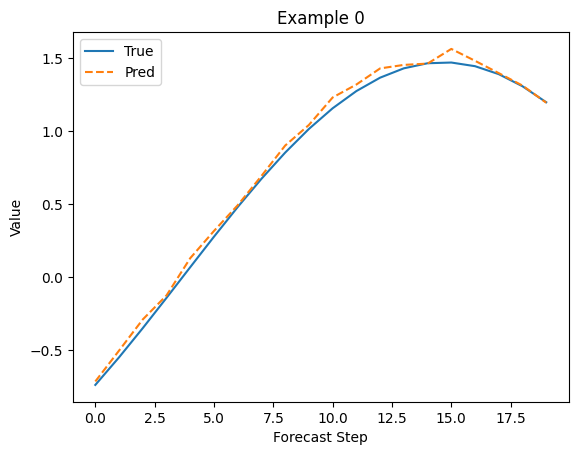

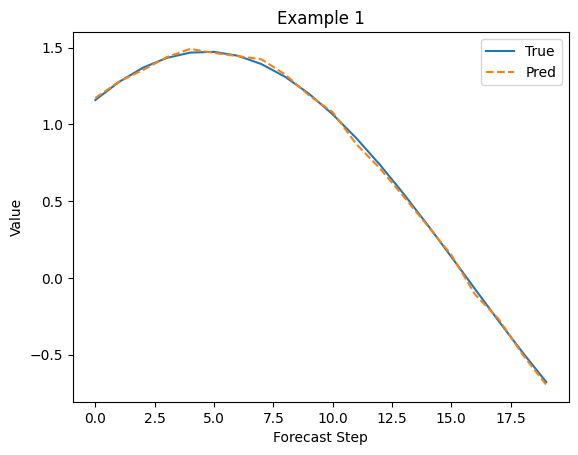

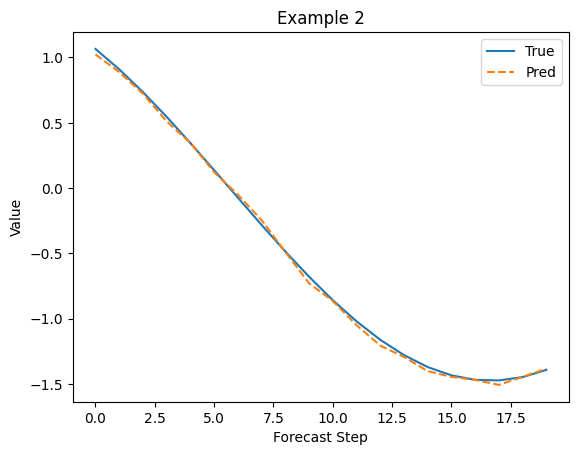

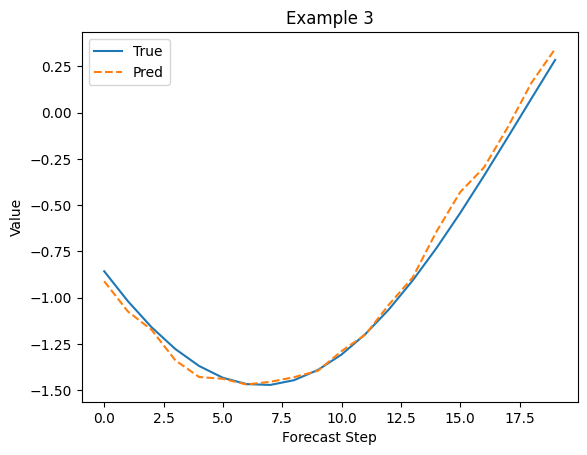

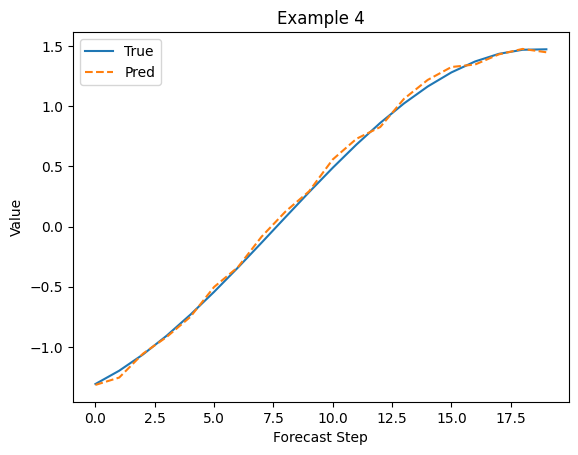

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.279423
Epoch 2/50 - Train Loss: 0.876070
Epoch 3/50 - Train Loss: 0.639361
Epoch 4/50 - Train Loss: 0.481887
Epoch 5/50 - Train Loss: 0.372863
Epoch 6/50 - Train Loss: 0.278225
Epoch 7/50 - Train Loss: 0.197649
Epoch 8/50 - Train Loss: 0.126860
Epoch 9/50 - Train Loss: 0.081932
Epoch 10/50 - Train Loss: 0.062449
Epoch 11/50 - Train Loss: 0.048712
Epoch 12/50 - Train Loss: 0.041797
Epoch 13/50 - Train Loss: 0.039517
Epoch 14/50 - Train Loss: 0.035883
Epoch 15/50 - Train Loss: 0.031797
Epoch 16/50 - Train Loss: 0.032850
Epoch 17/50 - Train Loss: 0.031501
Epoch 18/50 - Train Loss: 0.028809
Epoch 19/50 - Train Loss: 0.026370
Epoch 20/50 - Train Loss: 0.023421
Epoch 21/50 - Train Loss: 0.021042
Epoch 22/50 - Train Loss: 0.019922
Epoch 23/50 - Train Loss: 0.017271
Epoch 24/50 - Train Loss: 0.019524
Epoch 25/50 - Train Loss: 0.018391
Epoch 26/50 - Train Loss: 0.019488
Epoch 27/50 - Train Loss: 0

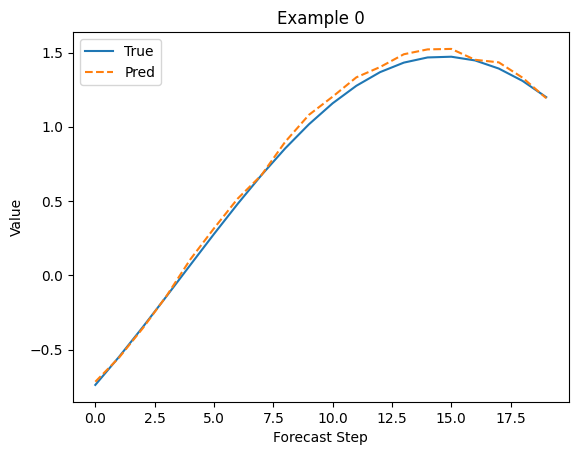

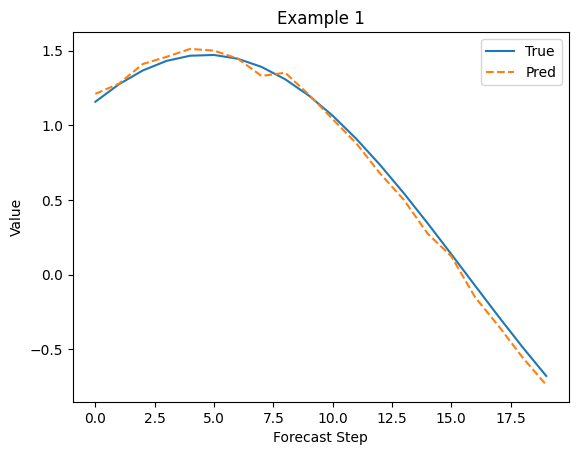

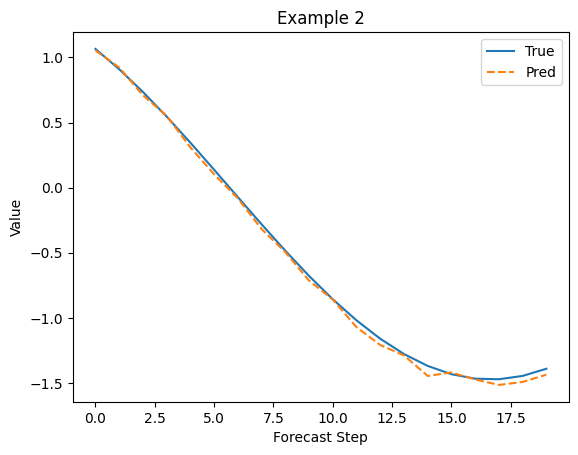

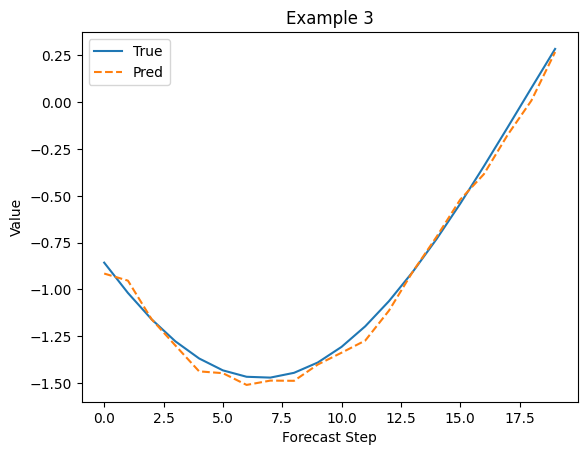

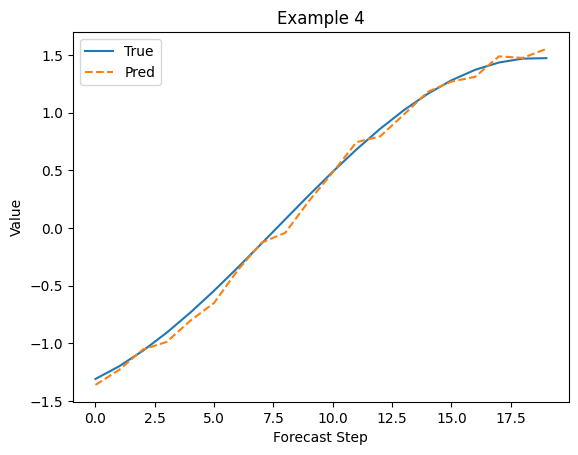

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.182606


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 2/50 - Train Loss: 0.749841
Epoch 3/50 - Train Loss: 0.456578
Epoch 4/50 - Train Loss: 0.262782
Epoch 5/50 - Train Loss: 0.152396
Epoch 6/50 - Train Loss: 0.096437
Epoch 7/50 - Train Loss: 0.064912
Epoch 8/50 - Train Loss: 0.045471
Epoch 9/50 - Train Loss: 0.038397
Epoch 10/50 - Train Loss: 0.035385
Epoch 11/50 - Train Loss: 0.035620
Epoch 12/50 - Train Loss: 0.034092
Epoch 13/50 - Train Loss: 0.031204
Epoch 14/50 - Train Loss: 0.029292
Epoch 15/50 - Train Loss: 0.027583
Epoch 16/50 - Train Loss: 0.025091
Epoch 17/50 - Train Loss: 0.022957
Epoch 18/50 - Train Loss: 0.021987
Epoch 19/50 - Train Loss: 0.018238
Epoch 20/50 - Train Loss: 0.017969
Epoch 21/50 - Train Loss: 0.017163
Epoch 22/50 - Train Loss: 0.017011
Epoch 23/50 - Train Loss: 0.018547
Epoch 24/50 - Train Loss: 0.017068
Epoch 25/50 - Train Loss: 0.015006
Epoch 26/50 - Train Loss: 0.015677
Epoch 27/50 - Train Loss: 0.015646
Epoch 28/50 - Train Loss: 0.015491
Epoch 29/50 - Train Loss: 0.014543
Epoch 30/50 - Train Loss: 0.

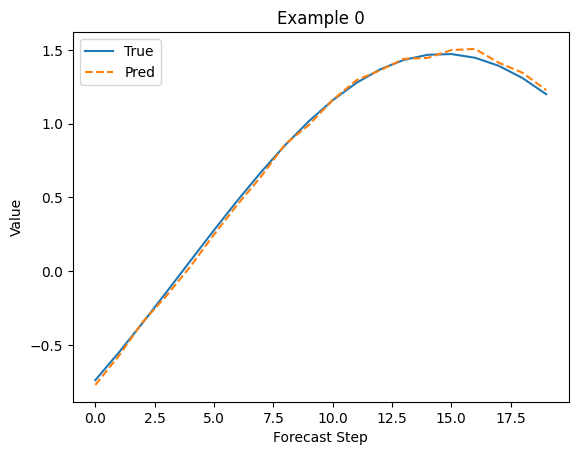

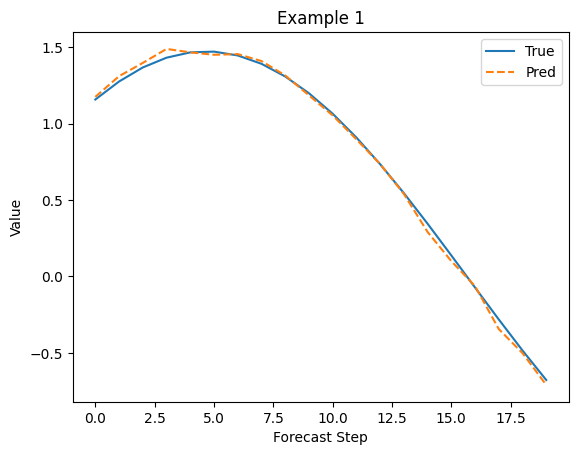

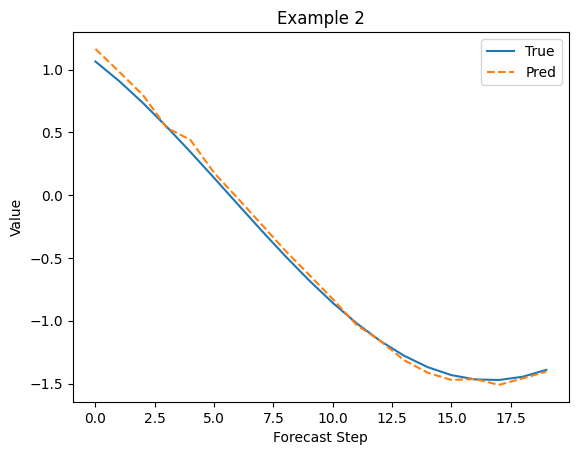

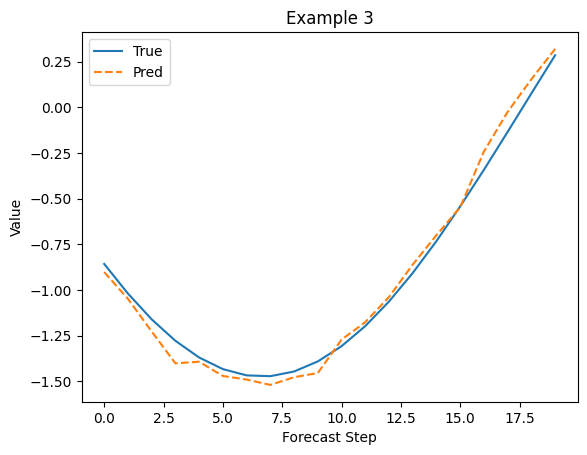

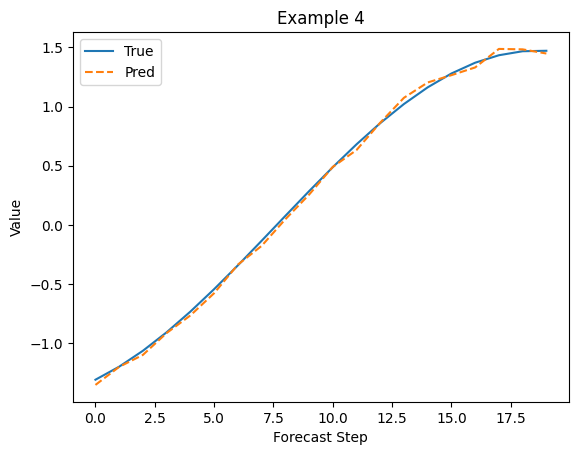

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.280882
Epoch 2/50 - Train Loss: 0.908408
Epoch 3/50 - Train Loss: 0.664693
Epoch 4/50 - Train Loss: 0.468066
Epoch 5/50 - Train Loss: 0.314349
Epoch 6/50 - Train Loss: 0.206847
Epoch 7/50 - Train Loss: 0.122772
Epoch 8/50 - Train Loss: 0.077614
Epoch 9/50 - Train Loss: 0.047687
Epoch 10/50 - Train Loss: 0.039753
Epoch 11/50 - Train Loss: 0.040567
Epoch 12/50 - Train Loss: 0.036826
Epoch 13/50 - Train Loss: 0.038655
Epoch 14/50 - Train Loss: 0.037794
Epoch 15/50 - Train Loss: 0.036542
Epoch 16/50 - Train Loss: 0.030792
Epoch 17/50 - Train Loss: 0.028617
Epoch 18/50 - Train Loss: 0.026081
Epoch 19/50 - Train Loss: 0.022981
Epoch 20/50 - Train Loss: 0.020826
Epoch 21/50 - Train Loss: 0.019404
Epoch 22/50 - Train Loss: 0.019704
Epoch 23/50 - Train Loss: 0.022327
Epoch 24/50 - Train Loss: 0.020006
Epoch 25/50 - Train Loss: 0.018420
Epoch 26/50 - Train Loss: 0.018514
Epoch 27/50 - Train Loss: 0

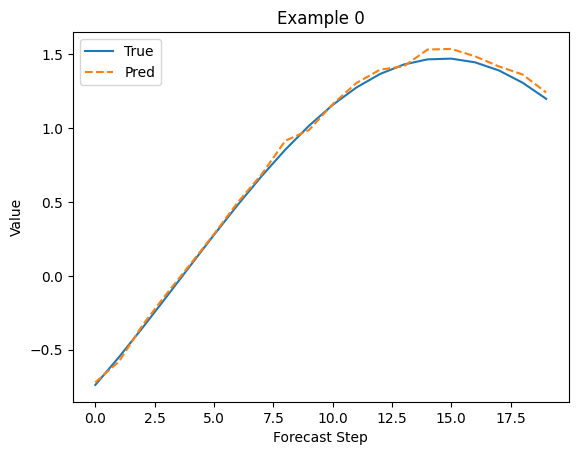

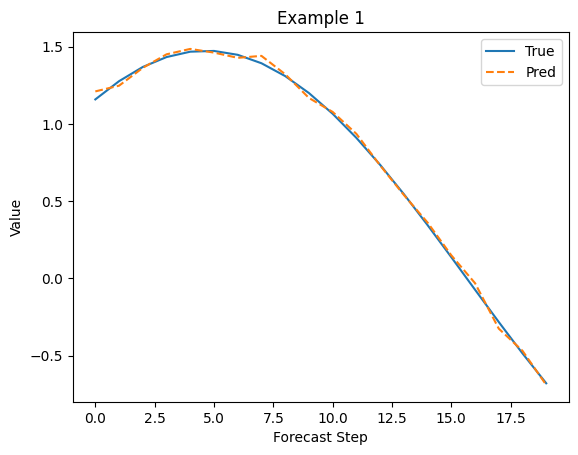

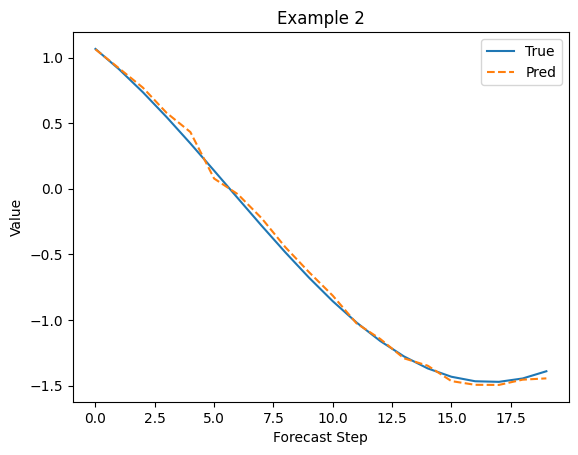

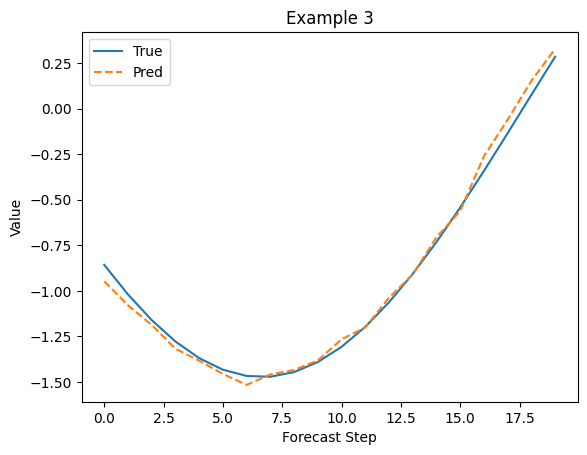

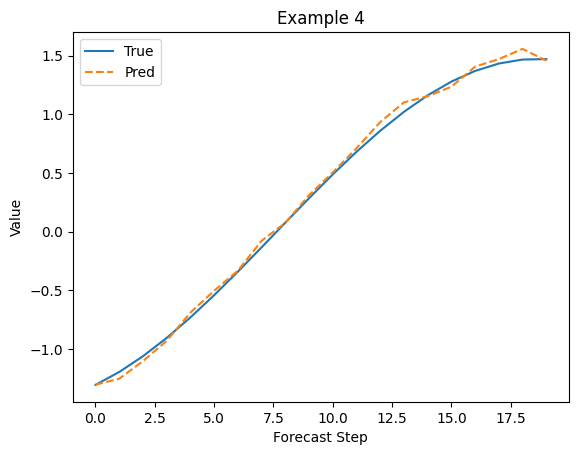

Loaded 94 sequences for 2 patients.
Loaded 47 sequences for 1 patients.
Epoch 1/50 - Train Loss: 1.453501


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 2/50 - Train Loss: 1.068252
Epoch 3/50 - Train Loss: 0.823033
Epoch 4/50 - Train Loss: 0.642517
Epoch 5/50 - Train Loss: 0.465593


In [ ]:
# === Imports ===
import torch
import torch.nn as nn

# === Hyper‑params (reuse yours) ===
batch_size     = 64
seq_len        = 20
forecast_steps = 20
epochs         = 50
lr             = 1e-3
device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Model & optimizer ===
model = TimeSeriesTransformer(
    feature_size=num_features,    # should be 5
    d_model=64,
    nhead=8,
    num_layers=3,
    dim_feedforward=128,
    dropout=0.1,
    forecast_steps=forecast_steps
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# === Train ===
print("▶️  Starting training …")
train_model(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=epochs
)

# === Evaluate ===
print("▶️  Evaluating on validation set …")
preds, trues = evaluate_model(
    model=model,
    dataloader=val_loader,
    device=device
)

# === Plot a few examples ===
plot_predictions(preds, trues, num_examples=5)


##TRANSFORMER FORECAST

## RECURSIVE FORECASTING AND NEXT STEPS



In [ ]:
# import matplotlib.pyplot as plt

# model.eval()

# # === Get One Batch from Val Loader ===
# x_sample, future_target_sample = next(iter(val_loader))
# x_sample, future_target_sample = x_sample.to(device), future_target_sample.to(device)

# with torch.no_grad():
#     pred_future = model(x_sample, forecast_len=future_target_sample.size(1))  # [batch_size, forecast_len, feature_dim]

# # === Plot Full Forecast for First Sequence and One Feature ===
# feature_idx = 1  # Change to visualize different feature
# forecast_len = future_target_sample.size(1)

# plt.figure(figsize=(10, 4))
# plt.plot(range(forecast_len), future_target_sample[0, :, feature_idx].cpu().numpy(), label="True Future")
# plt.plot(range(forecast_len), pred_future[0, :, feature_idx].cpu().numpy(), label="Predicted Future", linestyle='dashed', color='red')
# plt.title(f"{forecast_len}-Step Forecast vs Ground Truth (Feature {feature_idx})")
# plt.xlabel("Forecast Step")
# plt.ylabel("Feature Value")
# plt.grid()
# plt.legend()
# plt.show()


In [ ]:
def recursive_forecast_amplitude(model, x_init, steps=30, amplitude_idx=0):
    """
    Predict multiple future steps recursively using model's forecast head.

    Args:
        model: trained TransformerVAE model
        x_init: [batch_size, seq_len, feature_dim] - starting sequence
        steps: int - future steps to predict
        amplitude_idx: int - index of amplitude feature to extract

    Returns:
        preds: [batch_size, steps] - predicted amplitude values
    """

    model.eval()
    preds = []
    x_curr = x_init.clone().detach()

    with torch.no_grad():
        for _ in range(steps):
            recon, future_pred, _, _ = model(x_curr, forecast_len=20)  # Predict 1 step
            next_feat = future_pred[:, -1, :]  # Next predicted feature vector
            next_amp = next_feat[:, amplitude_idx]

            preds.append(next_amp.unsqueeze(1))
            x_curr = torch.cat([x_curr[:, 1:, :], next_feat.unsqueeze(1)], dim=1)

    preds = torch.cat(preds, dim=1)
    return preds

In [ ]:
import matplotlib.pyplot as plt

all = 50

amplitude_idx = clean_data.columns.get_loc('br_avg')  # Adjust this index based on your feature of interest

# Example sequence for context
example_seq = sequences[0].unsqueeze(0)  # [1, seq_len, feature_dim]

# True future amplitude for comparison
true_amplitude = data_tensor[seq_len : seq_len + all, amplitude_idx]

# Predict recursively
predicted_amplitude = recursive_forecast_amplitude(vae, example_seq, steps=all, amplitude_idx=amplitude_idx)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(all), true_amplitude.cpu(), label='True Amplitude', marker='o', markersize=3)
plt.plot(range(all), predicted_amplitude.squeeze(0).cpu(), label='Predicted Amplitude', marker='x', markersize=3)
plt.title(f"Recursive Sine Wave Amplitude Prediction ({all} Steps Ahead)")
plt.xlabel("Future Timestep")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

## MODEL KEY PARAMETERS AND RESULTS

#

# Test 1

vae = TransformerVAE(
    feature_dim=len(clean_data.columns),
    d_model=64,
    latent_dim=64,
    num_heads=4,
    num_layers=4, # this is what it was --> num_layers=4,
    dropout=0.3 # this is what it was --> dropout=0.1
)

RESULTS

Train batches: 6, Val batches: 2
Epoch 1: Train Loss 3.6648 (Recon 1.7641, Forecast 1.9006 | Val (Recon 0.9393, Forecast 1.0123)
Epoch 2: Train Loss 2.1266 (Recon 1.0240, Forecast 1.1026 | Val (Recon 0.6533, Forecast 0.6775)
Epoch 3: Train Loss 1.6026 (Recon 0.7809, Forecast 0.8217 | Val (Recon 0.5105, Forecast 0.5160)
Epoch 4: Train Loss 1.3135 (Recon 0.6410, Forecast 0.6725 | Val (Recon 0.4233, Forecast 0.4421)
Epoch 5: Train Loss 1.1273 (Recon 0.5440, Forecast 0.5833 | Val (Recon 0.3802, Forecast 0.3918)
Epoch 6: Train Loss 1.0028 (Recon 0.4843, Forecast 0.5185 | Val (Recon 0.3567, Forecast 0.3744)
Epoch 7: Train Loss 0.9370 (Recon 0.4440, Forecast 0.4930 | Val (Recon 0.3364, Forecast 0.3564)
Epoch 8: Train Loss 0.8704 (Recon 0.4131, Forecast 0.4573 | Val (Recon 0.3098, Forecast 0.3456)
Epoch 9: Train Loss 0.8376 (Recon 0.3926, Forecast 0.4450 | Val (Recon 0.3152, Forecast 0.3377)
Epoch 10: Train Loss 0.8011 (Recon 0.3777, Forecast 0.4234 | Val (Recon 0.3154, Forecast 0.3307)
Epoch 11: Train Loss 0.7756 (Recon 0.3695, Forecast 0.4061 | Val (Recon 0.3221, Forecast 0.3461)
Epoch 12: Train Loss 0.7624 (Recon 0.3599, Forecast 0.4025 | Val (Recon 0.3122, Forecast 0.3383)
Epoch 13: Train Loss 0.7537 (Recon 0.3524, Forecast 0.4013 | Val (Recon 0.3051, Forecast 0.3258)
Epoch 14: Train Loss 0.7271 (Recon 0.3442, Forecast 0.3829 | Val (Recon 0.3093, Forecast 0.3325)
Epoch 15: Train Loss 0.7279 (Recon 0.3400, Forecast 0.3878 | Val (Recon 0.3135, Forecast 0.3213)
Epoch 16: Train Loss 0.7008 (Recon 0.3330, Forecast 0.3678 | Val (Recon 0.3178, Forecast 0.3161)
Epoch 17: Train Loss 0.6900 (Recon 0.3270, Forecast 0.3631 | Val (Recon 0.2966, Forecast 0.3114)
Epoch 18: Train Loss 0.6816 (Recon 0.3237, Forecast 0.3579 | Val (Recon 0.3052, Forecast 0.2959)
Epoch 19: Train Loss 0.6642 (Recon 0.3144, Forecast 0.3498 | Val (Recon 0.3046, Forecast 0.3113)
Epoch 20: Train Loss 0.6690 (Recon 0.3022, Forecast 0.3668 | Val (Recon 0.2907, Forecast 0.2983)
Epoch 21: Train Loss 0.6395 (Recon 0.2947, Forecast 0.3448 | Val (Recon 0.2632, Forecast 0.3223)
Epoch 22: Train Loss 0.6105 (Recon 0.2809, Forecast 0.3296 | Val (Recon 0.2528, Forecast 0.2860)
Epoch 23: Train Loss 0.5907 (Recon 0.2677, Forecast 0.3229 | Val (Recon 0.2364, Forecast 0.2927)
Epoch 24: Train Loss 0.5744 (Recon 0.2521, Forecast 0.3223 | Val (Recon 0.2180, Forecast 0.2964)
Epoch 25: Train Loss 0.5506 (Recon 0.2380, Forecast 0.3126 | Val (Recon 0.2039, Forecast 0.2825)
Epoch 26: Train Loss 0.5395 (Recon 0.2256, Forecast 0.3140 | Val (Recon 0.1886, Forecast 0.2685)
Epoch 27: Train Loss 0.5170 (Recon 0.2137, Forecast 0.3032 | Val (Recon 0.1828, Forecast 0.2778)
Epoch 28: Train Loss 0.4975 (Recon 0.2008, Forecast 0.2967 | Val (Recon 0.1676, Forecast 0.2699)
Epoch 29: Train Loss 0.4749 (Recon 0.1896, Forecast 0.2854 | Val (Recon 0.1613, Forecast 0.2526)
Epoch 30: Train Loss 0.4614 (Recon 0.1804, Forecast 0.2810 | Val (Recon 0.1510, Forecast 0.2573)

Results saved successfully


## Previous loop without KL

vae = TransformerVAE(
    feature_dim=len(clean_data.columns),
    d_model=64,
    latent_dim=64,
    num_heads=4,
    num_layers=4, # this is what it was --> num_layers=4,
    dropout=0.3 # this is what it was --> dropout=0.1
)

optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
recon_loss_fn = nn.MSELoss()
forecast_loss_fn = nn.MSELoss()

results = []

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

for epoch in range(30):
    vae.train()
    epoch_loss, recon_loss_total, forecast_loss_total = 0, 0, 0

    for x, future_target in train_loader:

        recon, forecast, mu, logvar = vae(x, forecast_len=1)

        recon_loss = recon_loss_fn(recon, x)
        forecast_loss = forecast_loss_fn(forecast, future_target)
        loss = recon_loss + forecast_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        recon_loss_total += recon_loss.item()
        forecast_loss_total += forecast_loss.item()


    avg_loss = epoch_loss / len(train_loader)
    avg_recon = recon_loss_total / len(train_loader)
    avg_forecast = forecast_loss_total / len(train_loader)


    # 🔥 Validation Phase
    vae.eval()
    val_recon_total, val_forecast_total, val_kld_total = 0, 0, 0

    with torch.no_grad():
        for x_val, future_target_val in val_loader:
            recon_val, forecast_val, mu_val, logvar_val = vae(x_val, forecast_len=1)

            val_recon_loss = recon_loss_fn(recon_val, x_val)
            val_forecast_loss = forecast_loss_fn(forecast_val, future_target_val)
            val_kld = -0.5 * torch.mean(1 + logvar_val - mu_val.pow(2) - logvar_val.exp())

            val_recon_total += val_recon_loss.item()
            val_forecast_total += val_forecast_loss.item()
            val_kld_total += val_kld.item()

    avg_val_recon = val_recon_total / len(val_loader)
    avg_val_forecast = val_forecast_total / len(val_loader)
    avg_val_kld = val_kld_total / len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss {avg_loss:.4f} (Recon {avg_recon:.4f}, Forecast {avg_forecast:.4f} | Val (Recon {avg_val_recon:.4f}, Forecast {avg_val_forecast:.4f})")

    results.append({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "train_recon_loss": avg_recon,
        "train_forecast_loss": avg_forecast,
        "val_recon_loss": avg_val_recon,
        "val_forecast_loss": avg_val_forecast,
        "val_kld_loss": avg_val_kld
    })

Save results
import pandas as pd
results_df = pd.DataFrame(results)
results_df.to_csv("vae_dualdecoder_trainval.csv", index=False)
print("Results saved successfully")

![image.png](attachment:image.png)

# TEST 2 --> NEW LOOP

vae = TransformerVAE(
    feature_dim=len(clean_data.columns),
    d_model=128,
    latent_dim=128,
    num_heads=8,
    num_layers=6,
    dropout=0.2
)

optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
recon_loss_fn = nn.MSELoss()
forecast_loss_fn = nn.MSELoss()
beta = 0.01  # KL divergence weight, tune this as needed

results = []

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

for epoch in range(30):
    vae.train()
    epoch_loss, recon_loss_total, forecast_loss_total, kld_total = 0, 0, 0, 0

    for x, future_target in train_loader:
        
        recon, forecast, mu, logvar = vae(x, forecast_len=1)

        recon_loss = recon_loss_fn(recon, x)
        forecast_loss = forecast_loss_fn(forecast, future_target)
        kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        loss = recon_loss + forecast_loss + beta * kld

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        recon_loss_total += recon_loss.item()
        forecast_loss_total += forecast_loss.item()
        kld_total += kld.item()

    avg_loss = epoch_loss / len(train_loader)
    avg_recon = recon_loss_total / len(train_loader)
    avg_forecast = forecast_loss_total / len(train_loader)
    avg_kld = kld_total / len(train_loader)

    # 🔥 Validation Phase
    vae.eval()
    val_recon_total, val_forecast_total, val_kld_total = 0, 0, 0

    with torch.no_grad():
        for x_val, future_target_val in val_loader:
            recon_val, forecast_val, mu_val, logvar_val = vae(x_val, forecast_len=1)

            val_recon_loss = recon_loss_fn(recon_val, x_val)
            val_forecast_loss = forecast_loss_fn(forecast_val, future_target_val)
            val_kld = -0.5 * torch.mean(1 + logvar_val - mu_val.pow(2) - logvar_val.exp())

            val_recon_total += val_recon_loss.item()
            val_forecast_total += val_forecast_loss.item()
            val_kld_total += val_kld.item()

    avg_val_recon = val_recon_total / len(val_loader)
    avg_val_forecast = val_forecast_total / len(val_loader)
    avg_val_kld = val_kld_total / len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss {avg_loss:.4f} (Recon {avg_recon:.4f}, Forecast {avg_forecast:.4f}, KLD {avg_kld:.4f}) | Val (Recon {avg_val_recon:.4f}, Forecast {avg_val_forecast:.4f}, KLD {avg_val_kld:.4f})")

    results.append({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "train_recon_loss": avg_recon,
        "train_forecast_loss": avg_forecast,
        "train_kld_loss": avg_kld,
        "val_recon_loss": avg_val_recon,
        "val_forecast_loss": avg_val_forecast,
        "val_kld_loss": avg_val_kld
    })

# Save results
import pandas as pd
results_df = pd.DataFrame(results)
results_df.to_csv("vae_dualdecoder_trainval.csv", index=False)
print("Results saved successfully")


# RESULTS

# TEST 3


## I want to see if adding more data will improve my transformer


In [ ]:
# vae = TransformerVAE(
#     feature_dim=len(clean_data.columns),
#     d_model=64,
#     latent_dim=64,
#     num_heads=4, # Changed from 6 to 8
#     num_layers=4,
#     dropout=0.1
# )


# optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
# recon_loss_fn = nn.MSELoss()
# forecast_loss_fn = nn.MSELoss()
# beta = 0.01  # KL divergence weight, tune this as needed

# results = []

# print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# for epoch in range(30):
#     vae.train()
#     epoch_loss, recon_loss_total, forecast_loss_total, kld_total = 0, 0, 0, 0

#     for x, future_target in train_loader:

#         recon, forecast, mu, logvar = vae(x, forecast_len=1)

#         recon_loss = recon_loss_fn(recon, x)
#         forecast_loss = forecast_loss_fn(forecast, future_target)
#         kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

#         loss = recon_loss + forecast_loss + beta * kld

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         epoch_loss += loss.item()
#         recon_loss_total += recon_loss.item()
#         forecast_loss_total += forecast_loss.item()
#         kld_total += kld.item()

#     avg_loss = epoch_loss / len(train_loader)
#     avg_recon = recon_loss_total / len(train_loader)
#     avg_forecast = forecast_loss_total / len(train_loader)
#     avg_kld = kld_total / len(train_loader)

#     # 🔥 Validation Phase
#     vae.eval()
#     val_recon_total, val_forecast_total, val_kld_total = 0, 0, 0

#     with torch.no_grad():
#         for x_val, future_target_val in val_loader:
#             recon_val, forecast_val, mu_val, logvar_val = vae(x_val, forecast_len=1)

#             val_recon_loss = recon_loss_fn(recon_val, x_val)
#             val_forecast_loss = forecast_loss_fn(forecast_val, future_target_val)
#             val_kld = -0.5 * torch.mean(1 + logvar_val - mu_val.pow(2) - logvar_val.exp())

#             val_recon_total += val_recon_loss.item()
#             val_forecast_total += val_forecast_loss.item()
#             val_kld_total += val_kld.item()

#     avg_val_recon = val_recon_total / len(val_loader)
#     avg_val_forecast = val_forecast_total / len(val_loader)
#     avg_val_kld = val_kld_total / len(val_loader)

#     print(f"Epoch {epoch+1}: Train Loss {avg_loss:.4f} (Recon {avg_recon:.4f}, Forecast {avg_forecast:.4f}, KLD {avg_kld:.4f}) | Val (Recon {avg_val_recon:.4f}, Forecast {avg_val_forecast:.4f}, KLD {avg_val_kld:.4f})")

#     results.append({
#         "epoch": epoch + 1,
#         "train_loss": avg_loss,
#         "train_recon_loss": avg_recon,
#         "train_forecast_loss": avg_forecast,
#         "train_kld_loss": avg_kld,
#         "val_recon_loss": avg_val_recon,
#         "val_forecast_loss": avg_val_forecast,
#         "val_kld_loss": avg_val_kld
#     })

# # Save results
# import pandas as pd
# results_df = pd.DataFrame(results)
# results_df.to_csv("vae_dualdecoder_trainval.csv", index=False)
# print("Results saved successfully")

## Results got down to around 0.2

OLD NON WORKING VAE



## --> The one below is the Transformer VAE but it's not working


# import torch
# import torch.nn as nn
# import math

# # === Positional Encoding for continuous features ===
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, max_seq_length=5000):
#         super().__init__()
#         pe = torch.zeros(max_seq_length, d_model)
#         position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_seq_length, d_model]

#     def forward(self, x):
#         seq_len = x.size(1)
#         x = x + self.pe[:, :seq_len, :]
#         return x


# # === Transformer VAE with Dual-Head Decoder ===
# class TransformerVAE(nn.Module):
#     def __init__(self, feature_dim=4, d_model=64, latent_dim=16, num_heads=4, num_layers=2, dropout=0.1):
#         super().__init__()

#         self.input_proj = nn.Linear(feature_dim, d_model)
#         self.pos_encoder = PositionalEncoding(d_model)

#         encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=128, dropout=dropout)
#         self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

#         self.fc_mu = nn.Linear(d_model, latent_dim)
#         self.fc_logvar = nn.Linear(d_model, latent_dim)

#         self.latent_to_hidden = nn.Linear(latent_dim, d_model)

#         # Separate decoder layers for reconstruction and forecasting
#         decoder_layer_recon = nn.TransformerDecoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=128, dropout=dropout)
#         decoder_layer_forecast = nn.TransformerDecoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=128, dropout=dropout)

#         self.transformer_decoder_recon = nn.TransformerDecoder(decoder_layer_recon, num_layers=num_layers)
#         self.transformer_decoder_forecast = nn.TransformerDecoder(decoder_layer_forecast, num_layers=num_layers)

#         self.output_proj_recon = nn.Linear(d_model, feature_dim)
#         self.output_proj_forecast = nn.Linear(d_model, feature_dim)


#     def encode(self, x):
#         x = self.input_proj(x)
#         x = self.pos_encoder(x)
#         x = x.transpose(0, 1)  # [seq_len, batch_size, d_model]
#         encoded = self.transformer_encoder(x)
#         pooled = encoded.mean(dim=0)  # [batch_size, d_model]
#         mu = self.fc_mu(pooled)
#         logvar = self.fc_logvar(pooled)
#         return mu, logvar

#     def reparameterize(self, mu, logvar):
#         std = torch.exp(0.5 * logvar)
#         eps = torch.randn_like(std)
#         return mu + eps * std

#     def decode_reconstruct(self, z, seq_len, tgt_input):
#         hidden = self.latent_to_hidden(z).unsqueeze(0)  # [1, batch_size, d_model]
#         output = self.transformer_decoder_recon(tgt_input, memory=hidden)
#         output = self.output_proj_recon(output.transpose(0, 1))  # [batch_size, seq_len, feature_dim]
#         return output

#     def decode_forecast(self, z, forecast_len, teacher_forcing_ratio=0.0, future_target=None):
#         """
#         Autoregressive forecast with optional teacher forcing during training.

#         z: Latent vector [batch_size, latent_dim]
#         forecast_len: Number of steps to forecast
#         teacher_forcing_ratio: Probability to use ground truth at each step
#         future_target: Ground truth future [batch_size, forecast_len, feature_dim] (required if teacher_forcing_ratio > 0)
#         """
#         hidden = self.latent_to_hidden(z).unsqueeze(0)  # [1, batch_size, d_model]
#         batch_size = z.size(0)
#         outputs = []

#         prev_input = torch.zeros(1, batch_size, hidden.size(2), device=z.device)

#         for t in range(forecast_len):
#             out = self.transformer_decoder_forecast(prev_input, memory=hidden)
#             projected = self.output_proj_forecast(out.transpose(0, 1))  # [batch_size, 1, feature_dim]

#             outputs.append(projected.squeeze(1))  # [batch_size, feature_dim]

#             if future_target is not None and torch.rand(1).item() < teacher_forcing_ratio:
#                 prev_feature = self.input_proj(future_target[:, t, :]).unsqueeze(0)  # [1, batch_size, d_model]
#             else:
#                 prev_feature = self.input_proj(projected.squeeze(1)).unsqueeze(0)

#             prev_input = self.pos_encoder(prev_feature)

#         outputs = torch.stack(outputs, dim=1)  # [batch_size, forecast_len, feature_dim]
#         return outputs

#     def forward(self, x, forecast_len=20, teacher_forcing_ratio=0.0, future_target=None):
#         seq_len = x.size(1)
#         mu, logvar = self.encode(x)
#         z = self.reparameterize(mu, logvar)

#         x_input = self.input_proj(x)
#         x_input = self.pos_encoder(x_input)
#         x_input = x_input.transpose(0, 1)  # [seq_len, batch_size, d_model]

#         recon = self.decode_reconstruct(z, seq_len, tgt_input=x_input)
#         forecast = self.decode_forecast(z, forecast_len, teacher_forcing_ratio, future_target=future_target)

#         return recon, forecast, mu, logvar
